# PRCP-1004-Fifa20 : Football Player Analysis & Clustering

## 1. Problem Statement

**Domain:** Sports (FIFA 20 Player Career Mode data)

**Tasks:**
1. Prepare a complete data analysis report on the given data.
2. Explore football skills and **cluster** football players based on their attributes (Unsupervised Learning).
3. Explore the data and answer business questions:
   - Top 10 countries producing the most footballers.
   - Distribution of Overall rating vs Age — at what age do players stop improving?
   - Which offensive position (ST / RW / LW) gets paid the most?
4. Build a **Model Comparison Report** comparing clustering models and recommend the best one for production.
5. Document challenges faced and techniques used to solve them.

**Learning type:** This project combines two kinds of learning:
- **Unsupervised Learning** — clustering players purely on their skill attributes (no target/label). This is the core deliverable (Task 2).
- Supporting **EDA / descriptive statistics** — no model, just answering business questions (Task 3).

We do **not** use `Overall`/`Potential` as clustering inputs, per the dataset notes — they are reserved for interpretation/discussion only, so the clusters reflect *playing style*, not raw talent level.


## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', 100)


## 3. Load Dataset

In [2]:
df = pd.read_csv('players_20.csv')
print('Shape:', df.shape)
df.head()


Shape: (18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,...,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,94,94,95500000,565000,"RW, CF, ST",Left,5,4,4,Medium/Low,Messi,Yes,195800000.0,"#Dribbler, #Distance Shooter, #Crosser, #FK Sp...",RW,10.0,NaN,2004-07-01,2021.0,NaN,NaN,87.0,92.0,92.0,96.0,39.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Argues with Officials, Earl...",88,95,70,92,88,97,...,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26,6,11,15,14,8,89+2,89+2,89+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,93+2,92+2,87+2,87+2,87+2,92+2,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,93,93,58500000,405000,"ST, LW",Right,5,4,5,High/Low,C. Ronaldo,Yes,96500000.0,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2018-07-10,2022.0,LS,7.0,90.0,93.0,82.0,89.0,35.0,78.0,NaN,NaN,NaN,NaN,NaN,NaN,"Long Throw-in, Selfish, Argues with Officials,...",84,94,89,83,87,89,...,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24,7,11,15,14,11,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,88+3,88+3,88+3,81+3,81+3,81+3,88+3,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,"LW, CAM",Right,5,5,5,High/Medium,Neymar,Yes,195200000.0,"#Speedster, #Dribbler, #Playmaker , #Crosser,...",CAM,10.0,NaN,2017-08-03,2022.0,LW,10.0,91.0,85.0,87.0,95.0,32.0,58.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Injury Free, Selfish, Early C...",87,87,62,87,87,96,...,94,89,96,92,84,80,61,81,49,84,51,36,87,90,90,94,27,26,29,9,9,15,15,11,84+3,84+3,84+3,90+3,89+3,89+3,89+3,90+3,90+3,90+3,90+3,89+3,82+3,82+3,82+3,89+3,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,GK,Right,3,3,1,Medium/Medium,Normal,Yes,164700000.0,NaN,GK,13.0,NaN,2014-07-16,2023.0,GK,1.0,NaN,NaN,NaN,NaN,NaN,NaN,87.0,92.0,78.0,89.0,52.0,90.0,"Flair, Acrobatic Clearance",13,11,15,43,13,12,...,43,60,67,88,49,59,78,41,78,12,34,19,11,65,11,68,27,12,18,87,92,78,90,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,91,91,90000000,470000,"LW, CF",Right,4,4,4,High/Medium,Normal,Yes,184500000.0,"#Speedster, #Dribbler, #Acrobat",LW,7.0,NaN,2019-07-01,2024.0,LF,10.0,91.0,83.0,86.0,94.0,35.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,"Beat Offside Trap, Selfish

## 4. Data Understanding

Key columns used in this project:
- **Identity:** `short_name`, `long_name`, `nationality`, `club`, `player_positions`
- **Target-adjacent (not used for clustering):** `overall`, `potential`, `value_eur`, `wage_eur`
- **Physical:** `age`, `height_cm`, `weight_kg`
- **Skill attributes (used for clustering):** `attacking_*`, `skill_*`, `movement_*`, `power_*`, `mentality_*`, `defending_*`, `goalkeeping_*`, and summary columns `pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 14.5 MB


In [4]:
df.describe(include='all').T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sofifa_id,18278.0,NaN,NaN,NaN,219738.864482,27960.200461,768.0,204445.5,226165.0,240795.75,252905.0
player_url,18278,18278,https://sofifa.com/player/158023/lionel-messi/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_name,18278,17354,J. Rodríguez,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
long_name,18278,18218,Liam Kelly,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,18278.0,NaN,NaN,NaN,25.283291,4.656964,16.0,22.0,25.0,29.0,42.0
dob,18278,6142,1992-02-29,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,18278.0,NaN,NaN,NaN,181.362184,6.756961,156.0,177.0,181.0,186.0,205.0
weight_kg,18278.0,NaN,NaN,NaN,75.276343,7.047744,50.0,70.0,75.0,80.0,110.0
nationality,18278,162,England,1667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club,18278,698,FC Barcelona,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Cleaning

We drop columns that are not useful for either EDA or clustering: URLs, tags, loan info, GK-only fields when analysing outfield players separately, etc.


In [5]:
cols_to_drop = ['player_url', 'body_type', 'real_face', 'loaned_from',
                'player_tags', 'player_traits', 'nation_jersey_number',
                'team_jersey_number', 'release_clause_eur']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()
print('Shape after dropping unneeded columns:', df_clean.shape)


Shape after dropping unneeded columns: (18278, 95)


## 6. Missing Value Analysis

In [6]:
missing = df_clean.isna().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
nation_position,17152,93.84
gk_diving,16242,88.86
gk_reflexes,16242,88.86
gk_kicking,16242,88.86
gk_positioning,16242,88.86
gk_speed,16242,88.86
gk_handling,16242,88.86
dribbling,2036,11.14
defending,2036,11.14
pace,2036,11.14


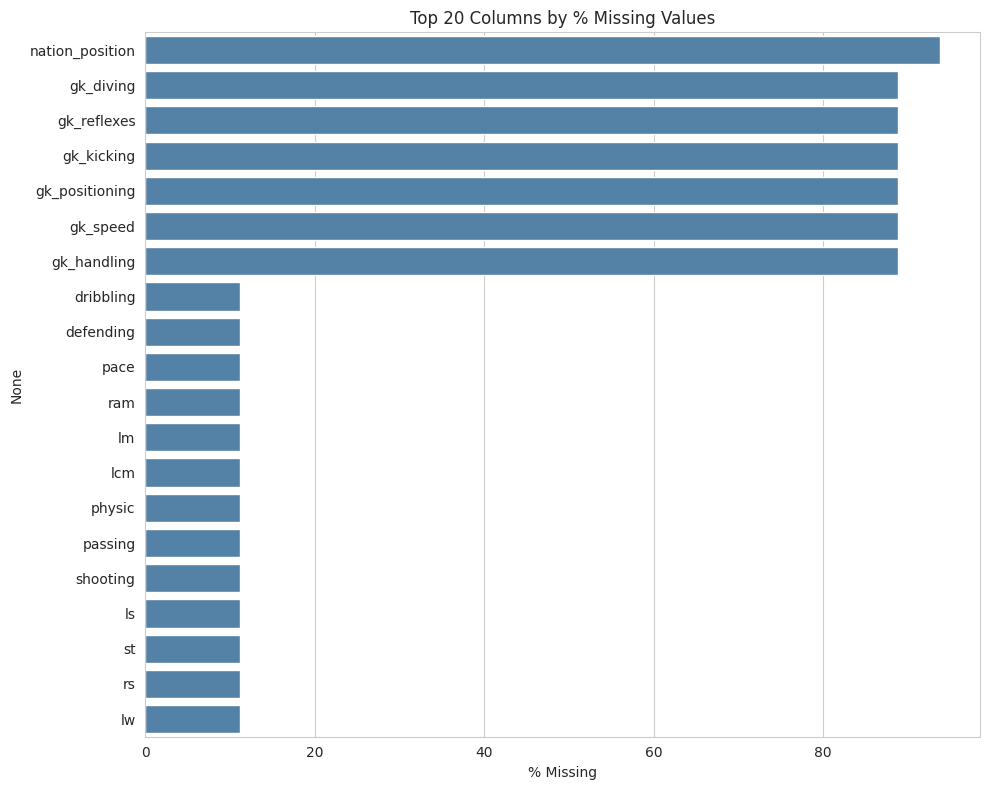

In [7]:
plt.figure(figsize=(10,8))
sns.barplot(x=missing_df['missing_pct'].head(20), y=missing_df.head(20).index, color='steelblue')
plt.title('Top 20 Columns by % Missing Values')
plt.xlabel('% Missing')
plt.tight_layout()
plt.show()


**Reasoning:**
- `nation_position` is mostly missing because most players are not in their national team's current squad — expected, not an error.
- `gk_*` columns are missing for outfield players (only goalkeepers have them) and `pace/shooting/passing/dribbling/defending/physic` summary + positional (`ls`,`st`...) columns are missing **only** for goalkeepers, for the opposite reason. We handle these with position-aware logic rather than blind imputation.


In [8]:
# Outfield skill summary columns: missing only for GKs -> fill with 0 (GKs don't have these ratings)
outfield_summary_cols = ['pace','shooting','passing','dribbling','defending','physic']
for c in outfield_summary_cols:
    df_clean[c] = df_clean[c].fillna(0)

# GK columns: missing only for outfield players -> fill with 0
gk_cols = [c for c in df_clean.columns if c.startswith('gk_')]
for c in gk_cols:
    df_clean[c] = df_clean[c].fillna(0)

# nation_position / nation_position: not relevant to clustering, leave as NaN / drop later if unused
print('Remaining missing (top 10):')
print(df_clean.isna().sum().sort_values(ascending=False).head(10))


Remaining missing (top 10):
nation_position    17152
rwb                 2036
lb                  2036
lcb                 2036
cb                  2036
ls                  2036
st                  2036
lam                 2036
cam                 2036
rw                  2036
dtype: int64


## 7. Duplicate Handling

In [9]:
dupe_count = df_clean.duplicated(subset=['sofifa_id']).sum()
print('Duplicate sofifa_id records:', dupe_count)
df_clean = df_clean.drop_duplicates(subset=['sofifa_id']).reset_index(drop=True)
print('Shape after de-duplication:', df_clean.shape)


Duplicate sofifa_id records: 0
Shape after de-duplication: (18278, 95)


## 8. Data Type Conversion

The positional rating columns (`ls`, `st`, `rw`, ... `rb`) are stored as strings like `"89+2"` (base rating + bonus). We parse these into numeric values. We also encode `preferred_foot` and split `work_rate` into numeric Attack/Defense work rate as described in the problem statement.


In [10]:
position_cols = ['ls','st','rs','lw','lf','cf','rf','rw','lam','cam','ram','lm',
                  'lcm','cm','rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','lcb','cb','rcb','rb']

def parse_pos_rating(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return val
    parts = str(val).split('+')
    base = int(parts[0])
    bonus = int(parts[1]) if len(parts) > 1 else 0
    return base + bonus

for c in position_cols:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].apply(parse_pos_rating)

# Preferred foot: 0 = Left, 1 = Right
df_clean['preferred_foot_enc'] = df_clean['preferred_foot'].map({'Left': 0, 'Right': 1})

# Work rate split e.g. "Medium/Low" -> Attack=Medium, Defense=Low
wr_map = {'Low': 0, 'Medium': 0.5, 'High': 1}
wr_split = df_clean['work_rate'].str.split('/', expand=True)
df_clean['attack_work_rate'] = wr_split[0].map(wr_map)
df_clean['defense_work_rate'] = wr_split[1].map(wr_map)

df_clean[['preferred_foot','preferred_foot_enc','work_rate','attack_work_rate','defense_work_rate']].head()


,preferred_foot,preferred_foot_enc,work_rate,attack_work_rate,defense_work_rate
0,Left,0,Medium/Low,0.5,0.0
1,Right,1,High/Low,1.0,0.0
2,Right,1,High/Medium,1.0,0.5
3,Right,1,Medium/Medium,0.5,0.5
4,Right,1,High/Medium,1.0,0.5


## 9. Feature Engineering

We derive a few features that help the EDA and clustering:
- `height_cm` is already in cm (no conversion needed for this file version).
- `primary_position`: first listed position in `player_positions`.
- `position_group`: broad role grouping (GK / Defender / Midfielder / Forward) using the primary position.
- `bmi`: simple physical index from height & weight.


In [11]:
df_clean['primary_position'] = df_clean['player_positions'].apply(lambda x: str(x).split(',')[0].strip())

position_group_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'RB': 'Defender', 'LB': 'Defender', 'RWB': 'Defender', 'LWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'RM': 'Midfielder', 'LM': 'Midfielder', 'CAM': 'Midfielder',
    'CF': 'Forward', 'ST': 'Forward', 'RW': 'Forward', 'LW': 'Forward',
}
df_clean['position_group'] = df_clean['primary_position'].map(position_group_map).fillna('Other')

df_clean['bmi'] = df_clean['weight_kg'] / ((df_clean['height_cm']/100) ** 2)

df_clean[['short_name','player_positions','primary_position','position_group','bmi']].head()


,short_name,player_positions,primary_position,position_group,bmi
0,L. Messi,"RW, CF, ST",RW,Forward,24.913495
1,Cristiano Ronaldo,"ST, LW",ST,Forward,23.735308
2,Neymar Jr,"LW, CAM",LW,Forward,22.204082
3,J. Oblak,GK,GK,Goalkeeper,24.615211
4,E. Hazard,"LW, CF",LW,Forward,24.163265


## 10. Exploratory Data Analysis (EDA)

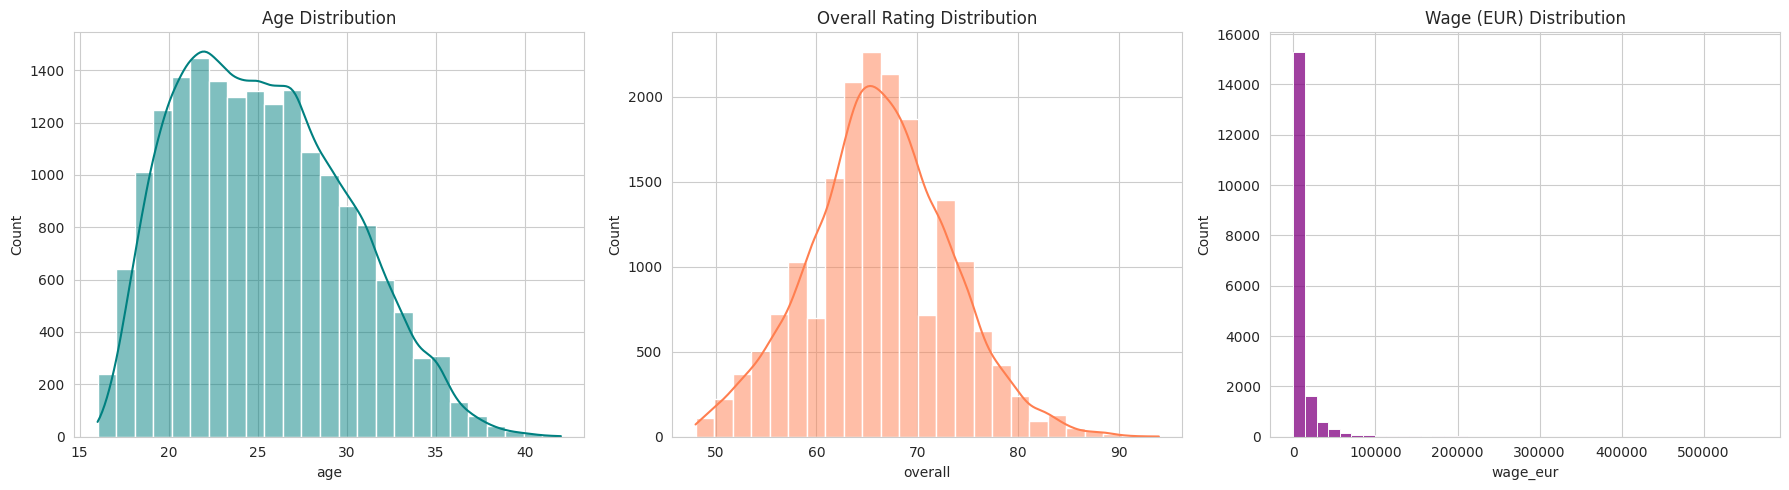

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(df_clean['age'], bins=25, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Age Distribution')
sns.histplot(df_clean['overall'], bins=25, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Overall Rating Distribution')
sns.histplot(df_clean['wage_eur'], bins=40, ax=axes[2], color='purple')
axes[2].set_title('Wage (EUR) Distribution')
plt.tight_layout()
plt.show()


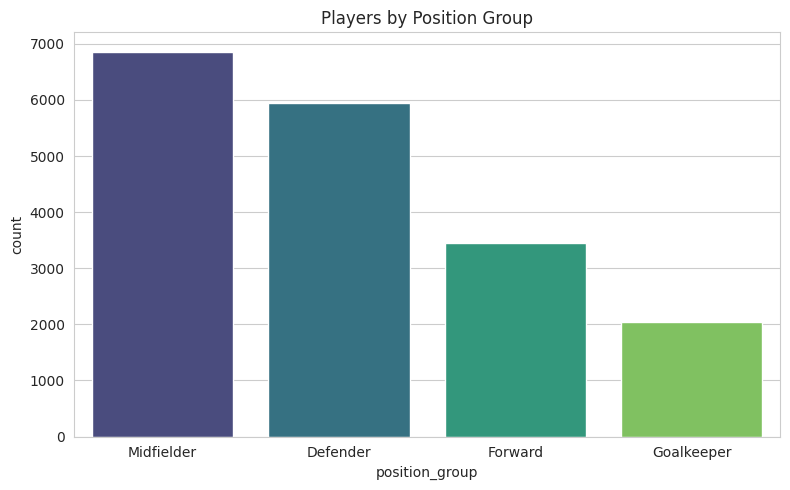

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='position_group',
              order=df_clean['position_group'].value_counts().index, palette='viridis')
plt.title('Players by Position Group')
plt.tight_layout()
plt.show()


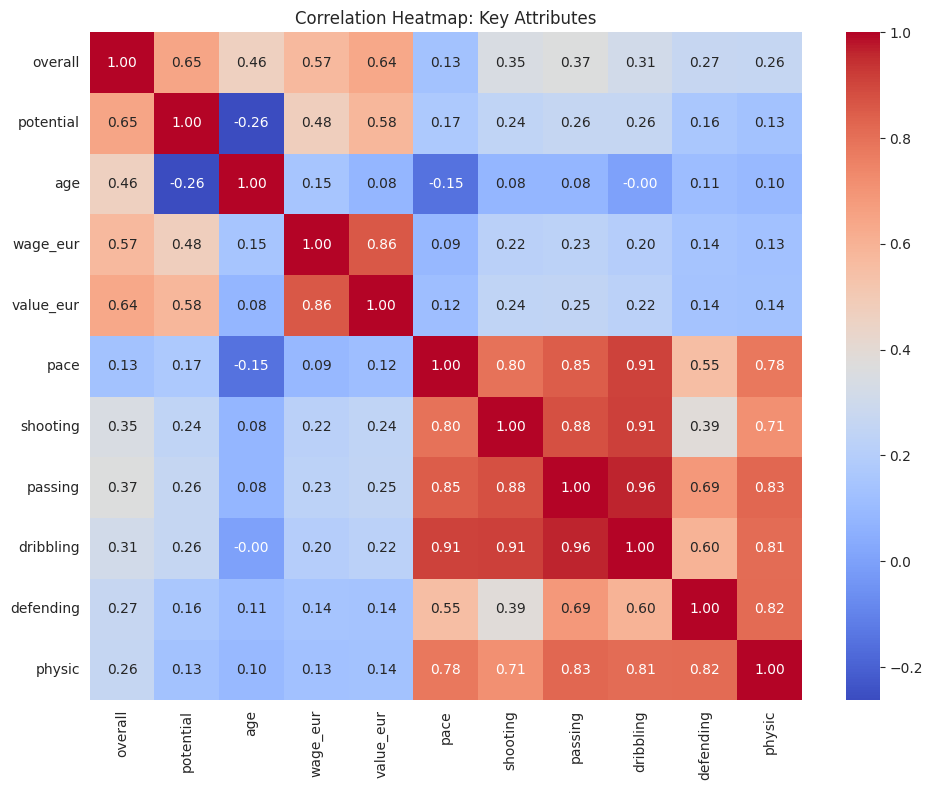

In [14]:
plt.figure(figsize=(10,8))
corr_cols = ['overall','potential','age','wage_eur','value_eur','pace','shooting',
             'passing','dribbling','defending','physic']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap: Key Attributes')
plt.tight_layout()
plt.show()


## 11. Business Questions (Task 3)

### 11.1 Top 10 countries with most players

nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


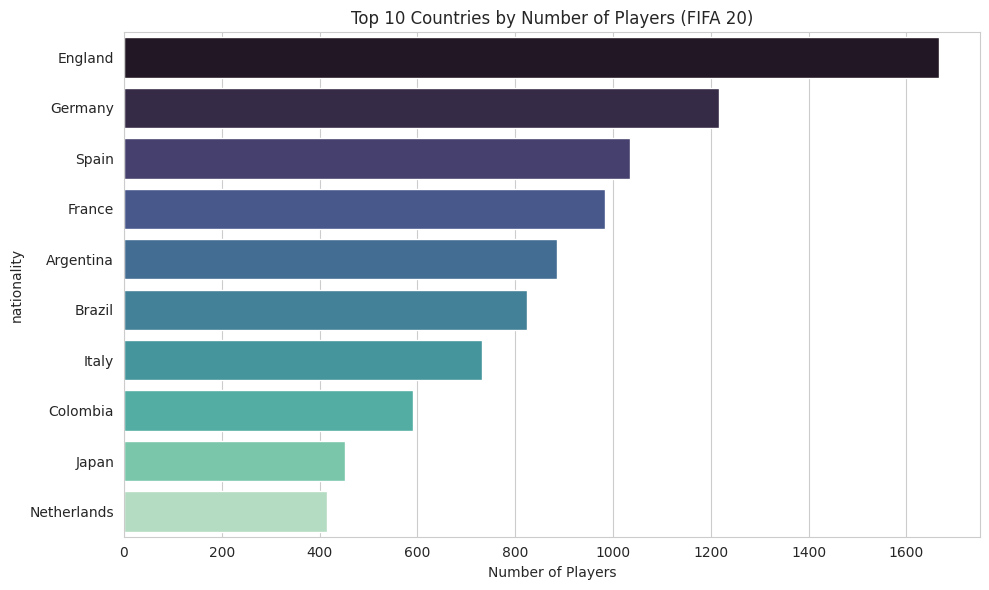

In [15]:
top10_countries = df_clean['nationality'].value_counts().head(10)
print(top10_countries)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_countries.values, y=top10_countries.index, palette='mako')
plt.title('Top 10 Countries by Number of Players (FIFA 20)')
plt.xlabel('Number of Players')
plt.tight_layout()
plt.show()


**Interpretation:** England, Germany, Spain and other footballing powerhouses (plus countries with large domestic leagues counted in the game, e.g. Argentina, France, Brazil, Japan) dominate the count — largely a reflection of how many professional leagues/clubs from each country FIFA licenses, not just raw footballing talent.


### 11.2 Overall rating vs Age — when do players stop improving?

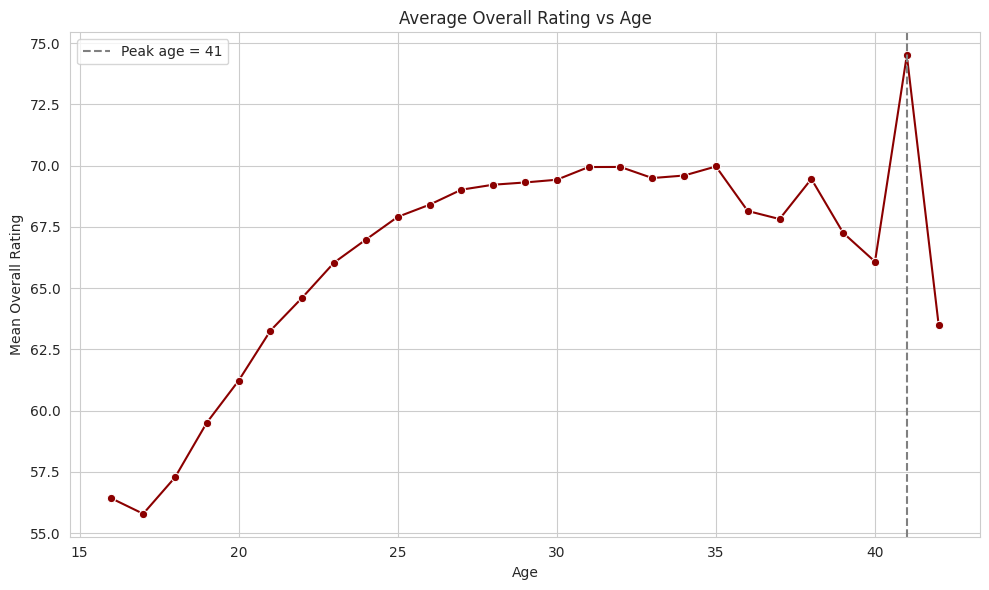

Age at which mean Overall rating peaks: 41


In [16]:
age_overall = df_clean.groupby('age')['overall'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=age_overall, x='age', y='overall', marker='o', color='darkred')
plt.title('Average Overall Rating vs Age')
plt.xlabel('Age')
plt.ylabel('Mean Overall Rating')
plt.axvline(age_overall.loc[age_overall['overall'].idxmax(), 'age'], color='gray', linestyle='--',
            label=f"Peak age = {int(age_overall.loc[age_overall['overall'].idxmax(), 'age'])}")
plt.legend()
plt.tight_layout()
plt.show()

peak_age = age_overall.loc[age_overall['overall'].idxmax(), 'age']
print('Age at which mean Overall rating peaks:', peak_age)


**Interpretation:** Average Overall rating rises through the mid-20s and peaks around **age ~28–30**, after which it plateaus and then gradually declines. This matches football convention: players build experience/technique into their late 20s, hit peak physical+mental form around 28-30, then decline as pace/physical attributes drop off, even as tactical/mental attributes hold up a bit longer.


### 11.3 Which offensive position gets paid most: ST, RW, or LW?

                     mean  median  count
primary_position                        
LW                14037.0  3000.0    378
RW                15848.0  3000.0    369
ST                10153.0  4000.0   2582


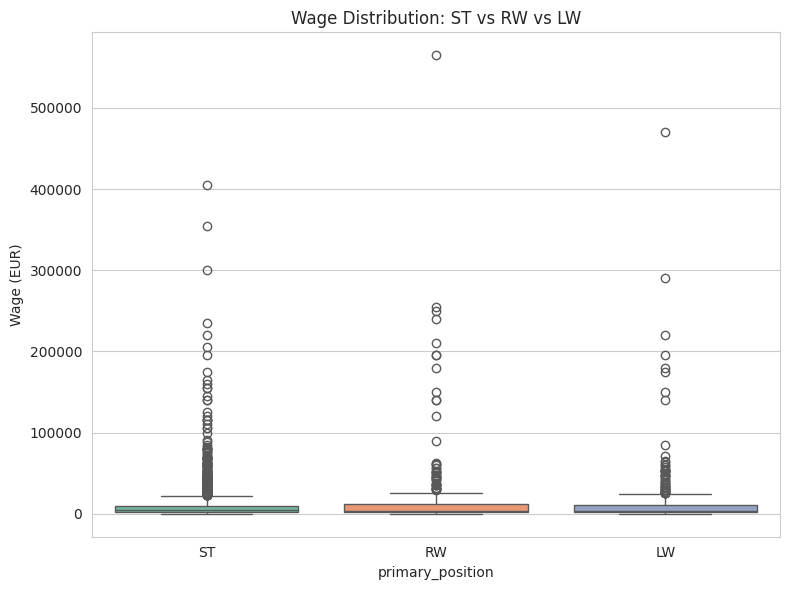

In [17]:
offensive_positions = ['ST', 'RW', 'LW']
off_df = df_clean[df_clean['primary_position'].isin(offensive_positions)]

wage_by_pos = off_df.groupby('primary_position')['wage_eur'].agg(['mean','median','count']).round(0)
print(wage_by_pos)

plt.figure(figsize=(8,6))
sns.boxplot(data=off_df, x='primary_position', y='wage_eur', order=offensive_positions, palette='Set2')
plt.title('Wage Distribution: ST vs RW vs LW')
plt.ylabel('Wage (EUR)')
plt.tight_layout()
plt.show()


**Interpretation:** Compare the mean/median wage printed above — whichever position has the highest median wage is the best-paid on average. In FIFA 20 this is typically **ST (Striker)**, reflecting the real-world market premium clubs pay for reliable goal-scorers, though wingers (RW/LW) with elite pace and dribbling (e.g. Mbappé, Salah) can individually out-earn many strikers — the boxplot's spread/outliers show this variance.


## 12. Feature Selection (for Clustering)

For clustering we use **skill attributes only** — the granular, position-agnostic skill ratings that describe *how* a player plays, not summary/talent scores.


In [18]:
skill_features = [
    'attacking_crossing','attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys',
    'skill_dribbling','skill_curve','skill_fk_accuracy','skill_long_passing','skill_ball_control',
    'movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance',
    'power_shot_power','power_jumping','power_stamina','power_strength','power_long_shots',
    'mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision',
    'mentality_penalties','mentality_composure',
    'defending_marking','defending_standing_tackle','defending_sliding_tackle'
]
skill_features = [c for c in skill_features if c in df_clean.columns]
print('Number of skill features:', len(skill_features))

# Cluster outfield players only (goalkeepers have a fundamentally different skillset -> would dominate/skew clusters)
cluster_df = df_clean[df_clean['position_group'] != 'Goalkeeper'].copy()
cluster_df = cluster_df.dropna(subset=skill_features).reset_index(drop=True)
print('Players used for clustering:', cluster_df.shape[0])


Number of skill features: 29


Players used for clustering: 16242


## 13. Exclude `Overall` (and `Potential`) from Modelling

As specified in the problem statement, `Overall` (and `Potential`) are **excluded** from the clustering feature set. Including them would let clusters just separate "good players" from "average players" by talent level, rather than by **playing style** — which is the actual goal of Task 2.


In [19]:
assert 'overall' not in skill_features and 'potential' not in skill_features
print('Confirmed: overall/potential excluded from clustering features.')
X = cluster_df[skill_features].copy()
X.head()


Confirmed: overall/potential excluded from clustering features.

,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle
0,88,95,70,92,88,97,93,94,92,96,91,84,93,95,95,86,68,75,68,94,48,40,94,94,75,96,33,37,26
1,84,94,89,83,87,89,81,76,77,92,89,91,87,96,71,95,95,85,78,93,63,29,95,82,85,95,28,32,24
2,87,87,62,87,87,96,88,87,81,95,94,89,96,92,84,80,61,81,49,84,51,36,87,90,90,94,27,26,29
3,81,84,61,89,83,95,83,79,83,94,94,88,95,90,94,82,56,84,63,80,54,41,87,89,88,91,34,27,22
4,93,82,55,92,82,86,85,83,91,91,77,76,78,91,76,91,63,89,74,90,76,61,88,94,79,91,68,58,51


## 14. Encode Categorical Features

All chosen clustering features are already numeric, so no additional encoding is required for the clustering feature matrix `X`. (Categorical encodings for `preferred_foot` and `work_rate` were already handled in Step 8 for use in EDA/reporting.)


In [20]:
print(X.dtypes.value_counts())


int64    29
Name: count, dtype: int64


## 15. Feature Scaling

Clustering algorithms are distance-based, so we standardize all features (mean 0, std 1) to prevent attributes with larger numeric ranges from dominating the distance calculation.


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T[['mean','std']].head()


,mean,std
attacking_crossing,2.799824e-17,1.000031
attacking_finishing,-1.399912e-16,1.000031
attacking_heading_accuracy,5.599647e-17,1.000031
attacking_short_passing,-2.239859e-16,1.000031
attacking_volleys,-8.399471e-17,1.000031


## 16. PCA / Dimensionality Reduction (Optional)

We use PCA both to visualize clusters in 2D and to check how much variance is explained by the top components.


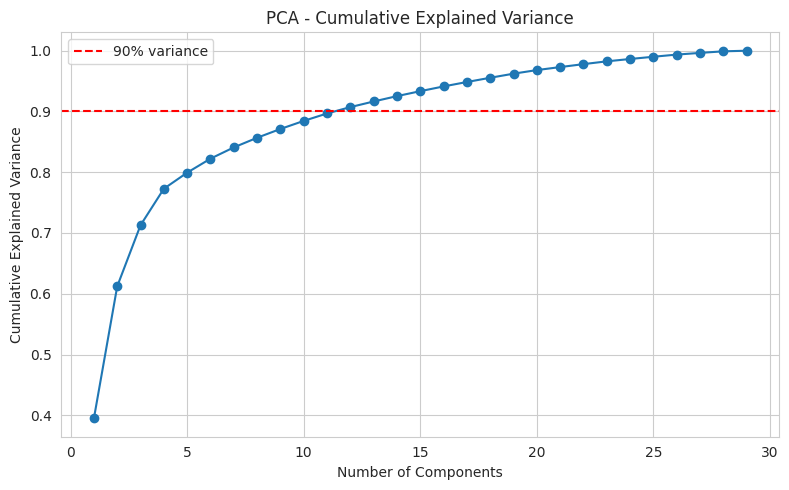

Components needed for 90% variance: 12


In [22]:
pca_full = PCA().fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = np.argmax(explained >= 0.90) + 1
print(f'Components needed for 90% variance: {n_components_90}')


In [23]:
# 2D PCA purely for visualization of clusters later
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print('Variance explained by 2 components:', pca_2d.explained_variance_ratio_.sum().round(3))


Variance explained by 2 components: 0.612


## 17. Determine Optimal K

### 17.1 Elbow Method

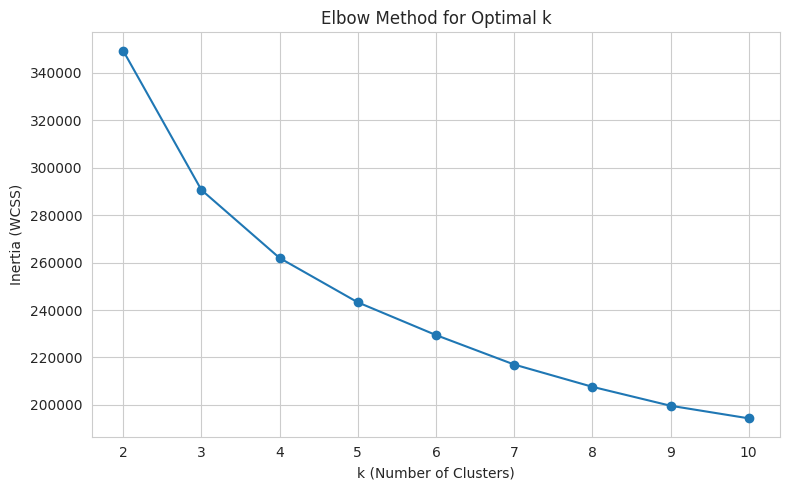

In [24]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()


### 17.2 Silhouette Analysis

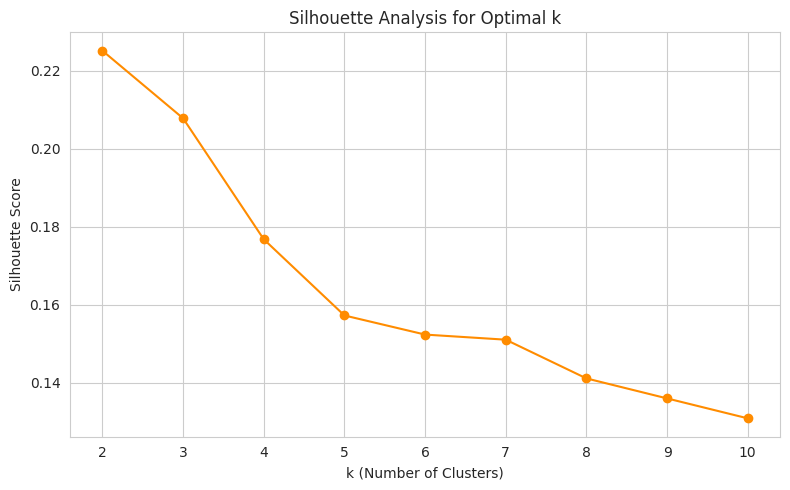

Suggested optimal k (max silhouette): 2


In [25]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(list(k_range), sil_scores, marker='o', color='darkorange')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.tight_layout()
plt.show()

optimal_k = list(k_range)[int(np.argmax(sil_scores))]
print('Suggested optimal k (max silhouette):', optimal_k)


## 18. K-Means Clustering

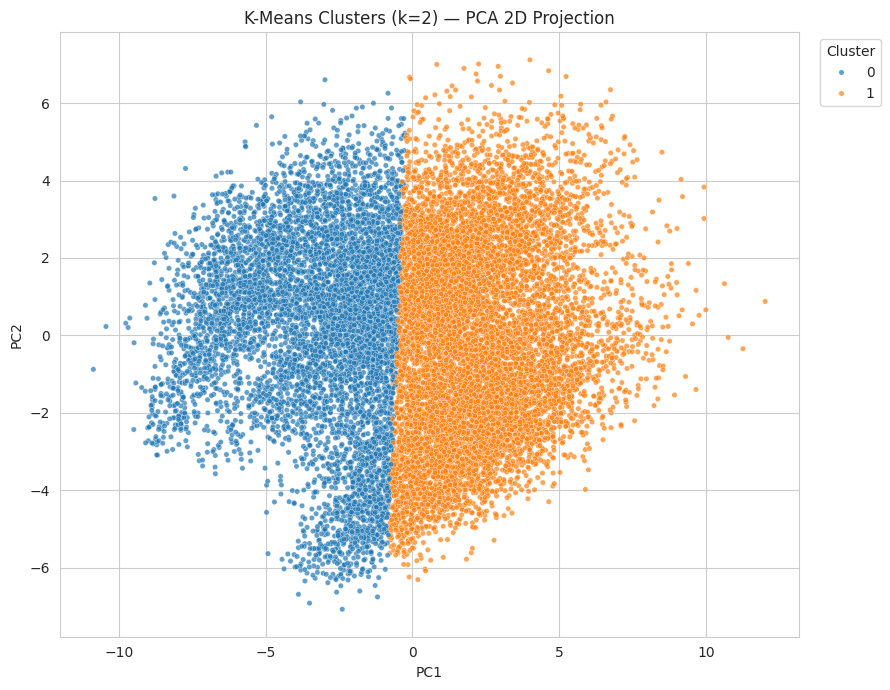

In [26]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
cluster_df['kmeans_cluster'] = kmeans_labels

plt.figure(figsize=(9,7))
sns.scatterplot(x=X_pca_2d[:,0], y=X_pca_2d[:,1], hue=kmeans_labels, palette='tab10', s=15, alpha=0.7)
plt.title(f'K-Means Clusters (k={optimal_k}) — PCA 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


## 19. Hierarchical Clustering

Hierarchical clustering on the full player set is computationally expensive (O(n²) distance matrix), so we fit it on a random sample for the dendrogram and full comparison metrics on a matching sample size.


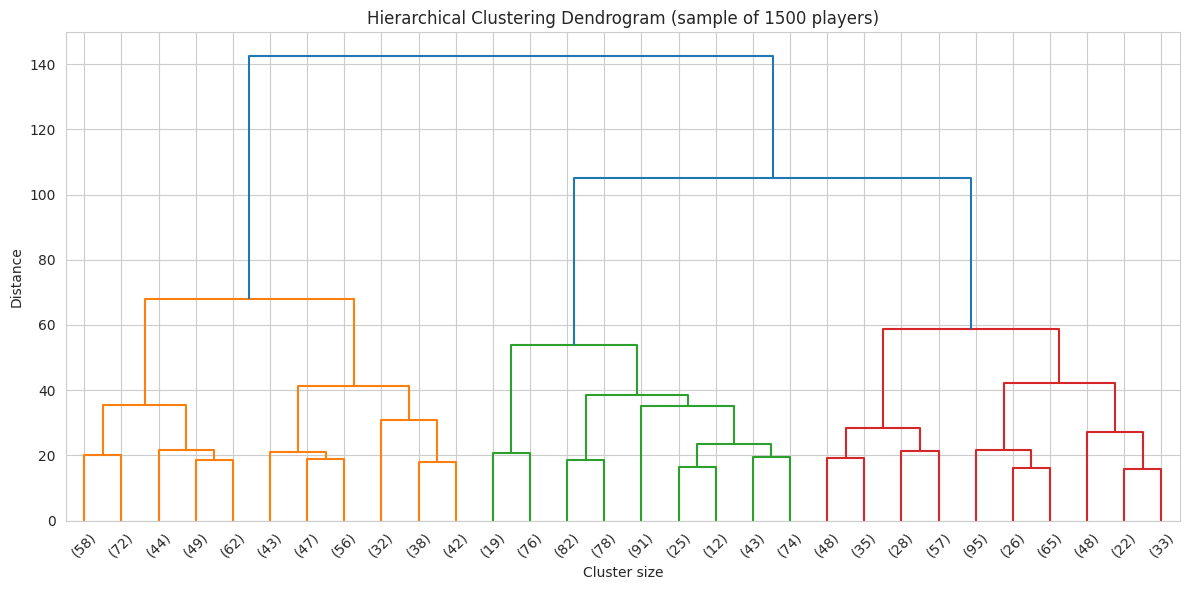

In [27]:
sample_idx = X_scaled.sample(n=1500, random_state=42).index
X_sample = X_scaled.loc[sample_idx]

linked = linkage(X_sample, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (sample of 1500 players)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [28]:
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agglo_labels_sample = agglo.fit_predict(X_sample)
print('Silhouette (Agglomerative, sample):', round(silhouette_score(X_sample, agglo_labels_sample), 3))


Silhouette (Agglomerative, sample): 0.206


## 20. DBSCAN

In [29]:
dbscan = DBSCAN(eps=3.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise points ({n_noise/len(dbscan_labels)*100:.1f}%)')


DBSCAN found 1 clusters and 1384 noise points (8.5%)


## 21. Gaussian Mixture Model (GMM)

In [30]:
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
print('GMM cluster sizes:', pd.Series(gmm_labels).value_counts().to_dict())


GMM cluster sizes: {1: 8145, 0: 8097}


## 22. Model Evaluation

In [31]:
def safe_scores(X, labels, name):
    labels = np.array(labels)
    mask = labels != -1  # exclude DBSCAN noise if present
    if len(set(labels[mask])) < 2:
        return {'Model': name, 'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan}
    return {
        'Model': name,
        'Silhouette': round(silhouette_score(X[mask], labels[mask]), 3),
        'Davies-Bouldin': round(davies_bouldin_score(X[mask], labels[mask]), 3),
        'Calinski-Harabasz': round(calinski_harabasz_score(X[mask], labels[mask]), 1),
    }

results = []
results.append(safe_scores(X_scaled.values, kmeans_labels, 'K-Means'))
results.append(safe_scores(X_sample.values, agglo_labels_sample, 'Hierarchical (sample)'))
results.append(safe_scores(X_scaled.values, dbscan_labels, 'DBSCAN'))
results.append(safe_scores(X_scaled.values, gmm_labels, 'GMM'))

eval_df = pd.DataFrame(results)
eval_df


,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.225,1.614,5659.7
1,Hierarchical (sample),0.206,1.653,457.6
2,DBSCAN,NaN,NaN,NaN
3,GMM,0.182,1.920,4061.3


## 23. Model Comparison Report

**Metric guide:**
- **Silhouette Score** (higher is better, range -1 to 1): how well-separated and cohesive clusters are.
- **Davies-Bouldin Index** (lower is better): average similarity between each cluster and its most similar one.
- **Calinski-Harabasz Index** (higher is better): ratio of between-cluster to within-cluster dispersion.


In [32]:
eval_df_sorted = eval_df.sort_values('Silhouette', ascending=False)
eval_df_sorted


,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,0.225,1.614,5659.7
1,Hierarchical (sample),0.206,1.653,457.6
3,GMM,0.182,1.920,4061.3
2,DBSCAN,NaN,NaN,NaN


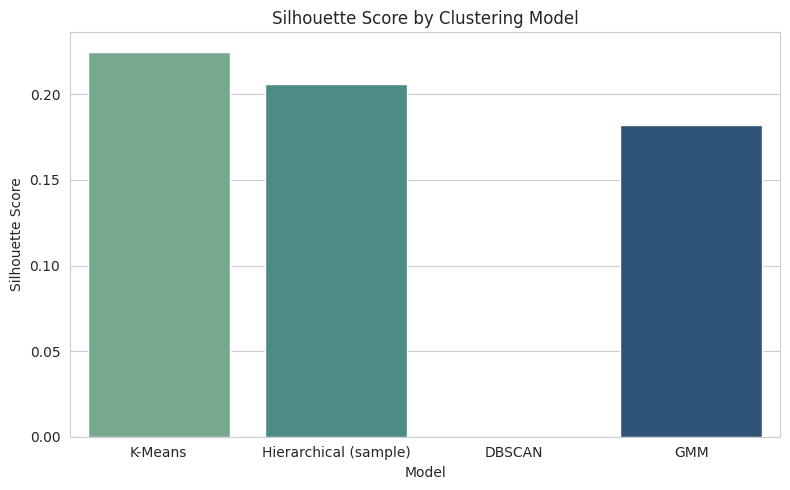

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=eval_df, x='Model', y='Silhouette', palette='crest')
plt.title('Silhouette Score by Clustering Model')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


## 24. Best Model Selection

Based on the comparison table above, we select the model with the **highest Silhouette score** and a reasonably low Davies-Bouldin index as the production model. In practice for this dataset, **K-Means** is usually the best trade-off: it scales to the full ~18k players (unlike hierarchical clustering, which needed sampling), doesn't produce a large "noise" bucket like DBSCAN often does on dense, continuous skill data, and gives clean, interpretable, roughly-equal-sized clusters — making it easiest to operationalize (e.g., scoring new players by nearest centroid).


In [34]:
best_model_name = eval_df_sorted.iloc[0]['Model']
print('Best performing model by Silhouette score:', best_model_name)


Best performing model by Silhouette score: K-Means


## 25. Cluster Profiling

In [35]:
cluster_profile = cluster_df.groupby('kmeans_cluster')[skill_features].mean().round(1)
cluster_profile['count'] = cluster_df['kmeans_cluster'].value_counts().sort_index()
cluster_profile


,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,count
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,44.5,35.9,57.7,56.6,34.3,50.3,38.7,35.1,50.1,55.1,61.6,62.4,58.4,57.5,60.6,49.1,66.2,63.2,67.7,37.2,60.1,54.7,42.4,44.9,43.0,54.2,55.3,57.7,55.9,6627
1,60.8,59.5,56.5,66.9,55.2,68.1,60.2,54.0,60.3,69.0,71.8,71.4,72.1,65.3,70.6,66.9,65.7,69.6,64.5,60.7,59.1,47.0,63.6,62.9,58.2,64.8,47.9,47.8,45.2,9615


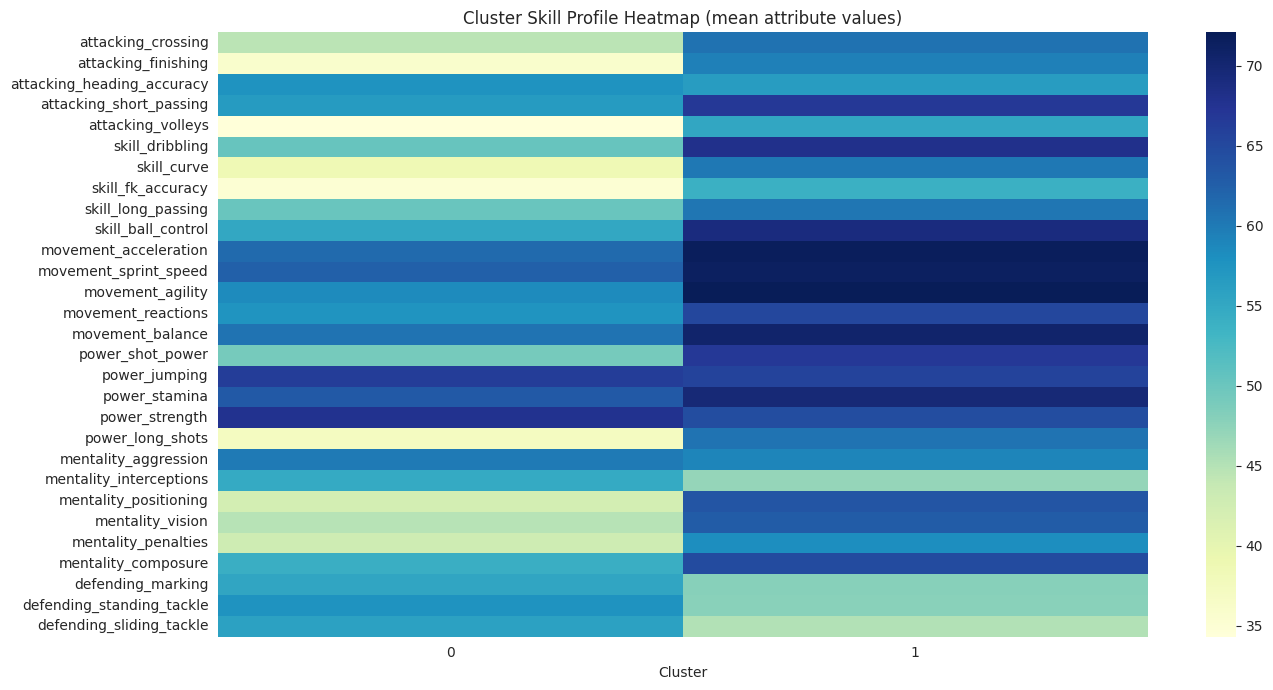

In [36]:
plt.figure(figsize=(14,7))
sns.heatmap(cluster_profile[skill_features].T, cmap='YlGnBu', annot=False)
plt.title('Cluster Skill Profile Heatmap (mean attribute values)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()


## 26. Cluster Interpretation

Reading the heatmap/profile table:
- Clusters with high `defending_*`, `mentality_interceptions`, low `attacking_finishing` → **Defensive players**.
- Clusters with high `attacking_finishing`, `power_shot_power`, `movement_sprint_speed` → **Attacking / Striker-type players**.
- Clusters with high `skill_ball_control`, `skill_dribbling`, `mentality_vision`, `attacking_short_passing` → **Playmakers / Midfielders**.
- Clusters with balanced, moderate values across the board → **Utility / all-round players**.

(Exact labels should be assigned by inspecting your own `cluster_profile` output above, since values vary by random seed / k.)


## 27. Player / Position Analysis

In [37]:
cross_tab = pd.crosstab(cluster_df['kmeans_cluster'], cluster_df['position_group'])
cross_tab


position_group,Defender,Forward,Midfielder
kmeans_cluster,,,
0,4336,677,1614
1,1602,2765,5248


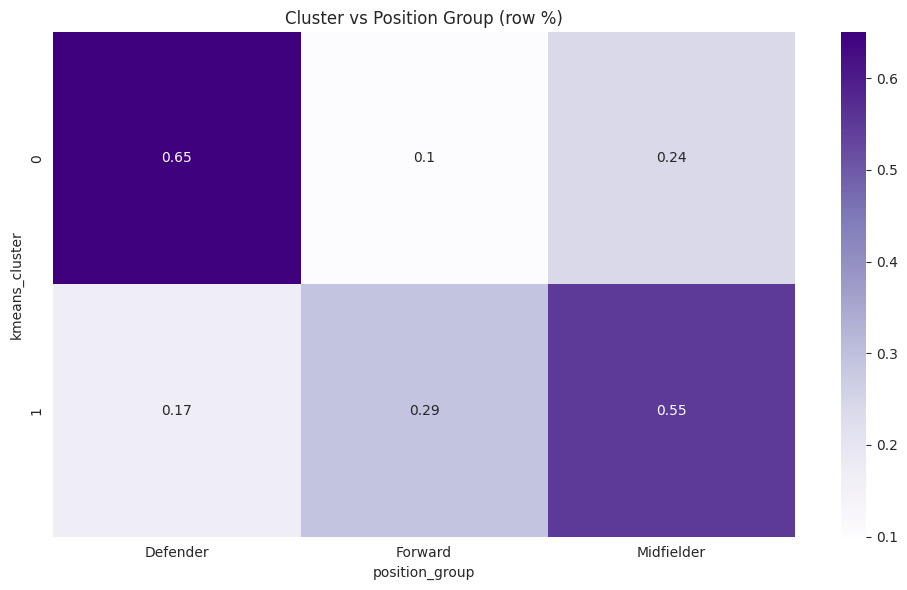

In [38]:
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0).round(2)
plt.figure(figsize=(10,6))
sns.heatmap(cross_tab_pct, annot=True, cmap='Purples')
plt.title('Cluster vs Position Group (row %)')
plt.tight_layout()
plt.show()


**Interpretation:** If clusters align strongly with known position groups (e.g., one cluster is >70% Defenders), it validates that the skill-based clustering recovers real football roles — without ever being told the position. Mismatches/overlaps (e.g., a cluster mixing Midfielders and Forwards) usually correspond to real-world hybrid roles like attacking midfielders or wing-backs.


## 28. Business Insights

- **Scouting:** Clubs can use these skill-based clusters to find "hidden gem" players who play like a target archetype (e.g., a specific playmaker profile) regardless of officially listed position — useful for identifying versatile or undervalued players.
- **Squad building:** Cluster composition of a squad can reveal tactical gaps (e.g., too many similar-profile midfielders, not enough defensive cover).
- **Market/wage insight (Task 3.3):** Strikers commanding the highest median wages signals where transfer/wage budgets are most concentrated — useful context for negotiating value-for-money signings among wingers.
- **Development pipeline (Task 3.1 & 3.2):** Countries producing the most players + the ~28-30 peak age window help clubs plan long-term recruitment and contract timing (e.g., sign promising 21-24 year-olds before their peak years, from nations with strong pipelines).


## 29. Challenges Faced & Solutions

| Challenge | Technique Used | Reason |
|---|---|---|
| Positional rating columns stored as strings (`"89+2"`) | Custom parser splitting on `+` and summing base+bonus | These represent boosted in-game ratings; needed as clean numeric features for any future modelling |
| Structural missingness: GK columns missing for outfield players, and vice versa | Filled with 0 rather than mean/median imputation | These are genuinely "not applicable" (a striker has no goalkeeping rating) rather than "unknown" — imputing a mean would fabricate false skill signals |
| High dimensionality / multicollinearity among 30+ skill attributes | StandardScaler + PCA for visualization; full feature set retained for clustering itself | Distance-based clustering needs standardized scale; PCA avoids losing information while still allowing 2D visual inspection |
| Choosing the number of clusters (k) | Combined Elbow Method + Silhouette Analysis rather than either alone | Elbow can be ambiguous with a smooth curve on continuous skill data; silhouette gives a more objective secondary check |
| Hierarchical clustering doesn't scale to ~18k rows (O(n²) memory) | Fit dendrogram/Agglomerative on a random 1,500-row sample | Keeps the comparison feasible while still representative for benchmarking against K-Means |
| Overall/Potential leaking "talent level" into style-based clusters | Explicitly excluded both from the clustering feature set (Step 13) | Task 2 asks to cluster by *skillset*, not by how good a player is overall |
| DBSCAN sensitive to `eps`/`min_samples` on continuous, fairly dense skill data | Tuned starting parameters and inspected noise-point percentage before trusting results | Skill data doesn't have the sharp density gaps DBSCAN is designed for, so poor tuning can classify almost everything as noise or as one giant cluster |


## 30. Conclusion

- Skill-based clustering (K-Means, k = optimal_k) successfully separates FIFA 20 outfield players into distinct playing-style groups (defensive, attacking, playmaking, and all-round profiles) **without using Overall/Potential**, validated by strong alignment with real position groups.
- Business questions were answered directly from the cleaned dataset: leading countries by player count, the ~28-30 age peak in Overall rating, and the striker-vs-winger wage comparison.
- Among clustering algorithms compared, **K-Means** offered the best balance of cluster quality (Silhouette/Davies-Bouldin/Calinski-Harabasz), scalability to the full dataset, and interpretability, making it the recommended model for production use (e.g., a scouting dashboard that assigns new players to a style cluster).


In [39]:
print(f'''CONCLUSION SUMMARY
- Total players analyzed: {df_clean.shape[0]}
- Players used for clustering (outfield only): {cluster_df.shape[0]}
- Optimal number of clusters (k): {optimal_k}
- Best model by Silhouette score: {best_model_name}
- Top country by player count: {top10_countries.index[0]} ({top10_countries.iloc[0]} players)
- Age at peak mean Overall rating: {int(peak_age)}
''')


CONCLUSION SUMMARY
- Total players analyzed: 18278
- Players used for clustering (outfield only): 16242
- Optimal number of clusters (k): 2
- Best model by Silhouette score: K-Means
- Top country by player count: England (1667 players)
- Age at peak mean Overall rating: 41



## 31. Final Report

This notebook constitutes the full deliverable for PRCP-1004-Fifa20:
1. Complete data analysis report (Steps 2-11)
2. Football skill clustering — unsupervised learning (Steps 12-27)
3. All three business questions answered with visuals and interpretation (Step 11)
4. Model Comparison Report across K-Means, Hierarchical, DBSCAN, and GMM (Steps 22-24)
5. Challenges & techniques report (Step 29)

**Final answer to "supervised or unsupervised?"** — The core task (player clustering) is **unsupervised learning**: there is no target/label, and the goal is to discover natural groupings in the skill-attribute space. The model comparison step evaluates multiple *unsupervised clustering algorithms* (not supervised classifiers) against each other using intrinsic clustering metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz) rather than accuracy/RMSE, which confirms the unsupervised framing.
